# Demonstration of the Coincidences Fast-Feedback Logic on the *Time Tagger X*

This notebook demonstrates the basic functionality of the coincidences  fast-feedback logic using the `FastFeedbackCoincidences` class. It uses the  internal test signal of the *Time Tagger X* to generate the coincidence events and the output pulses are fed back to the input channels 19 & 20 (Aux In 1 &  2)  to measure the latency. Therefore one needs to connect the Aux Out 1(2) to  the Aux In 1(2) channels on the backside of the device using a SMA cable.

The following three test measurements will be performed:

1. Measure the coincidence count rates of two different coincidence patterns. 
2. Record a trace of the `Scope` measurement class to visualize the coincidence events  and output pulse length.
3. Measure the input to output latency of the *Time Tagger X*.

## 0. Configure FastFeedbackCoincidences Parameters

Initialize the *Time Tagger X*:

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from Swabian.TimeTagger import *
from FastFeedbackCoincidences import FastFeedbackCoincidences

# Create the TimeTagger
serialNumber = "2328001508" #TTX2

ttx = createTimeTagger(serial=serialNumber)

Now the `FastFeedbackCoincidences` class is configured which writes the
corresponding parameters into the FPGA module. The fast-feedback module detects
triggered coincidences i.e. the event on the trigger channel (e.g. a laser sync
pulse) closes the coincidence window and an output pulse is generated with a
mean Trigger2Data latency of 85.7 ns (670 ps FWHM uniform jitter) after the
trigger event. Although, two independent coincidence patterns can be programmed,
the trigger channel and coincidence window size are the same for both.

A coincidence pattern is defined by a list of active channels (excluding the
trigger channel) and a list of coincidence channels which must be a subset of
the active channels. The channel numbering follows the standard scheme for all
Time Taggers i.e. channels 1 to 20 for rising edges and -1 to -20 for falling
edges. Further, a boolean flag for each coincidence pattern can be set to
discriminate between inclusive or exclusive coincidences. Inclusive here means
that an output pulse is emitted whenever events on the coincidence channels were
detected within the coincidence window regardless of further events on other
active channels. Different to that an exclusive coincidence event is defined as
no other events outside the coincidence group happen within the coincidence
window.

Finally, one of the Aux Out channels is assigned to each coincidence pattern and
the length of the output pulse can be chosen between 667 ps to 21.8 µs with 667
ps resolution. The output pulse has an amplitude of 1.5 V into 50 Ohm impedance.

The maximum rate of coincidence events is given by the maximum input frequency
of the *Time Tagger X* of 700 MHz and also depends on the coincidence window and
output pulse lengths.

In [11]:
# Enable FF logic
TRIGGER_CHANNEL = 1
COINC_WINDOW = 15e3

AUX_OUT_CANNEL_1 = 1
AUX_IN_CHANNEL_1 = 11
OUTPUT_PULS_LENGTH_1 = 10e3
ACTIVE_CHANNELS_1 = [2, 3, 4]  # trigger channel not needed here
COINC_MASK_1 = [3]
EXCLUSIVE_1 = True
AUX_OUT_CANNEL_2 = 2
AUX_IN_CHANNEL_2 = 12
OUTPUT_PULS_LENGTH_2 = 20e3
ACTIVE_CHANNELS_2 = [5, 6, 7, 8]
COINC_MASK_2 = [6, 7]
EXCLUSIVE_2 = False
FFC = FastFeedbackCoincidences(ttx, TRIGGER_CHANNEL, AUX_OUT_CANNEL_1, ACTIVE_CHANNELS_1, COINC_MASK_1, EXCLUSIVE_1, outputChannel2=AUX_OUT_CANNEL_2, activeChannels2=ACTIVE_CHANNELS_2, coincidenceGroup2=COINC_MASK_2, exclusiveCoincidence2=EXCLUSIVE_2, coincidenceWindow=COINC_WINDOW, outputPulseLength1=OUTPUT_PULS_LENGTH_1, outputPulseLength2=OUTPUT_PULS_LENGTH_2)

Note: The LEDs of channels 1 to 8 should be green now since these are the configured trigger and active channels, respectively.

Enable the test signal on a subset of channels to generate the trigger events and coincidence clicks. The following hardware delays are applied to the channels with activated test signal:
- Chs 3 & 4 delayed by 0 ns and 5 ns, respectively
- Chs 6, 7 & 8 delayed by 8 ns, 0 ns and 2 ns.

In [12]:
ttx.setTestSignal(TRIGGER_CHANNEL, True)  # coincidence trigger events
TRIGGER_DELAY = 10e3
ttx.setDelayHardware(TRIGGER_CHANNEL, TRIGGER_DELAY)
COINCIDENCE_DELAYS_1 = [0, 5e3]
for i, ch in enumerate(ACTIVE_CHANNELS_1[1:3]):
    ttx.setTestSignal(ch, True)
    ttx.setDelayHardware(ch, COINCIDENCE_DELAYS_1[i])
COINCIDENCE_DELAYS_2 = [8e3, 0, 2e3]
for i, ch in enumerate(ACTIVE_CHANNELS_2[1:4]):
    ttx.setTestSignal(ch, True)
    ttx.setDelayHardware(ch, COINCIDENCE_DELAYS_2[i])

Note: The LEDs above the trigger, the coincidence and the Aux Out channels should blink green now.

## 1. Measure Coincidence Count Rates

First, a measurement of the rates of detected coincidence events is performed by
measuring the count rates on the Aux Out channels (connected to the Aux In
channels 1 & 2 i.e. channel numbers 19 & 20).

*IMPORTANT: make sure the channels AuxOut 1 & 2 are connected to the AuxIn 1&2 channels by a short SMA cable!*

In [13]:
# Configure & run Countrate measurement
countrate = Countrate(ttx, [TRIGGER_CHANNEL, AUX_IN_CHANNEL_1, AUX_IN_CHANNEL_2])
countrate.startFor(1e11)
countrate.waitUntilFinished()

# Retrieve data
rates = countrate.getData() * 1e-3
print("------------------------------")
print(f"Count rate of coincidence trigger channel: {rates[0]} kcounts/s")
print(f"1st coincidence group count rate: {rates[1]} kcounts/s")
print(f"2nd coincidence group count rate: {rates[2]} kcounts/s")
print("------------------------------")

------------------------------
Count rate of coincidence trigger channel: 1033.06 kcounts/s
1st coincidence group count rate: 0.0 kcounts/s
2nd coincidence group count rate: 1205.07 kcounts/s
------------------------------


Remark: no counts are detected on channel Aux Out 1 since the coincidence pattern is defined as exclusive and there is always also an event on channel 4 detected within the coincidence window.

Now, the coincidence mask is changed to observe some coincidences also on this channel:

In [14]:
COINC_MASK_1 = [3, 4]
FFC.setCoincidenceGroup(AUX_OUT_CANNEL_1, ACTIVE_CHANNELS_1, COINC_MASK_1, EXCLUSIVE_1)

# Start measurement again
countrate.startFor(1e11)
countrate.waitUntilFinished()

# Retrieve data
rates = countrate.getData() * 1e-3
print("------------------------------")
print(f"Count rate of coincidence trigger channel: {rates[0]} kcounts/s")
print(f"1st coincidence group count rate: {rates[1]} kcounts/s")
print(f"2nd coincidence group count rate: {rates[2]} kcounts/s")
print("------------------------------")

------------------------------
Count rate of coincidence trigger channel: 1029.78 kcounts/s
1st coincidence group count rate: 1172.14 kcounts/s
2nd coincidence group count rate: 872.37 kcounts/s
------------------------------


## 2. Record Scope Traces

Next, the `Scope` measurement class of the API is used to visualize the timing of the input events as well as the output pulses.

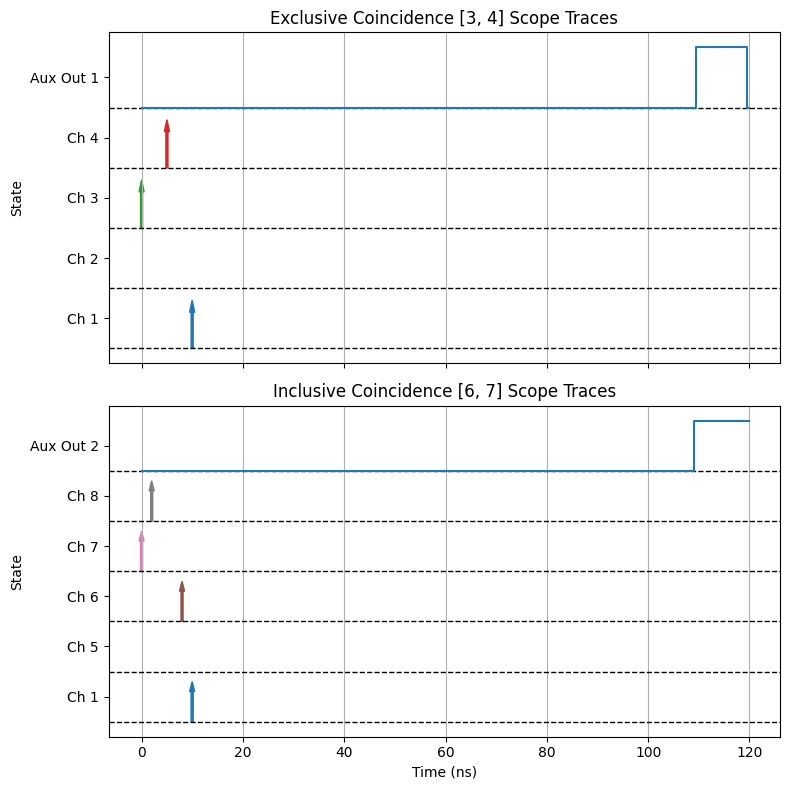

In [15]:
# Record a Scope measurement class trace to visualize the coincidence pattern and the output pulse length
WINDOW_SIZE = 120e3
MEASUREMENT_TIME_SCOPE = 10e6
scope_channels_1 = [TRIGGER_CHANNEL]+ ACTIVE_CHANNELS_1 + [AUX_IN_CHANNEL_1]
scope_1 = Scope(ttx, scope_channels_1, 3, window_size=WINDOW_SIZE, n_traces=1)
scope_channels_2 = [TRIGGER_CHANNEL] + ACTIVE_CHANNELS_2 + [AUX_IN_CHANNEL_2]
scope_2 = Scope(ttx, scope_channels_2, 7, window_size=WINDOW_SIZE, n_traces=1)

# Retrieve data and plot
scope_1.startFor(MEASUREMENT_TIME_SCOPE)
scope_1.waitUntilFinished()
scope_traces_1 = scope_1.getData()
scope_traces_2 = scope_2.getData()
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 8))

# Assign unique colors to each channel, repeating if necessary
all_channels = sorted(set(scope_channels_1 + scope_channels_2))
channel_colors = {ch: plt.cm.tab10(i % 10) for i, ch in enumerate(all_channels)}

for i, trace in enumerate(scope_traces_1[:-1]):
    axs[0].axhline(y=i, color='black', linestyle='--', linewidth=1)
    for event in trace:
        if event.state == 1:
            axs[0].arrow(event.time * 1e-3, i, 0, 0.6, width=0.4, head_width=1, head_length=0.2, fc=channel_colors[scope_channels_1[i]], ec=channel_colors[scope_channels_1[i]])
for i, event in enumerate(scope_traces_1[-1]):
    if i == 0:
        time = np.array([event.time * 1e-3])
        state = np.array([event.state%2])
    else:
        time = np.append(time, [event.time * 1e-3]*2)
        state = np.append(state, state[-1]%2)
        state = np.append(state, event.state%2)
time = np.append(time, WINDOW_SIZE * 1e-3)
state = np.append(state, state[-1])
y_offset = len(scope_traces_1) - 1
axs[0].axhline(y=y_offset, color='black', linestyle='--', linewidth=1)
axs[0].plot(time, state + y_offset)
axs[0].set_yticks(np.array(range(len(scope_channels_1))) + 0.5)
axs[0].set_yticklabels([f"Ch {ch}" for ch in scope_channels_1[:-1]] + [f"Aux Out {AUX_OUT_CANNEL_1}"])
axs[0].set_ylabel("State")
axs[0].set_title(f"Exclusive Coincidence {COINC_MASK_1} Scope Traces")
axs[0].grid(axis='x')

for i, trace in enumerate(scope_traces_2[:-1]):
    axs[1].axhline(y=i, color='black', linestyle='--', linewidth=1)
    for event in trace:
        if event.state == 1:
            axs[1].arrow(event.time * 1e-3, i, 0, 0.6, width=0.4, head_width=1, head_length=0.2, fc=channel_colors[scope_channels_2[i]], ec=channel_colors[scope_channels_2[i]])
for i, event in enumerate(scope_traces_2[-1]):
    if i == 0:
        time = np.array([event.time * 1e-3])
        state = np.array([event.state%2])
    else:
        time = np.append(time, [event.time * 1e-3]*2)
        state = np.append(state, state[-1]%2)
        state = np.append(state, event.state%2)
time = np.append(time, WINDOW_SIZE * 1e-3)
state = np.append(state, state[-1])
y_offset = len(scope_traces_2) - 1
axs[1].axhline(y=y_offset, color='black', linestyle='--', linewidth=1)
axs[1].plot(time, state + y_offset)
axs[1].set_yticks(np.array(range(len(scope_channels_2))) + 0.5)
axs[1].set_yticklabels([f"Ch {ch}" for ch in scope_channels_2[:-1]] + [f"Aux Out {AUX_OUT_CANNEL_2}"])
axs[1].set_xlabel("Time (ns)")
axs[1].set_ylabel("State")
axs[1].set_title(f"Inclusive Coincidence {COINC_MASK_2} Scope Traces")
axs[1].grid(axis='x')
plt.tight_layout()
plt.show()

One observes that the output pulse occurs about 86 ns after the trigger pulse on channel 1. Further, two different pulse lengths of the Aux Out 1 and Aux Out 2 pulses can be seen to be 10 ns and 20 ns, respectively, as configured above.

## 3. Determine the Trigger2Data Latency & Jitter

Finally, the Trigger2Data latency is measured which is defined as the time between the trigger event closing the coincidence window and the rising edges of the output pulses. Therefore, a `Histogram` between the trigger channel and the respective Aux Out channel is acquired.

In [16]:
def find_mean_fwhm(hist_index: np.ndarray, hist_data: np.ndarray):
    """

        Find the mean and full width at half maximum (FWHM) of a histogram.

        Parameters
        ----------
        hist_index: np.ndarray
            The time bins of the histogram.
        hist_data: np.ndarray
            The counts in each bin of the histogram.
            
        Returns
        -------
        mean: float
            The mean of the histogram.
        fwhm: float
            The full width at half maximum of the histogram.
    """
    # Normalize histogram and find mean
    if np.max(hist_data) != 0:
        hist_data = hist_data / np.max(hist_data)
    try:
        mean = np.average(hist_index, weights=hist_data)
    except ZeroDivisionError:
        mean = float(0)
    peak_idx = np.where(hist_index >= mean)[0][0]
    peak_counts = hist_data[peak_idx]

    # Calculate FWHM
    half_max = peak_counts / 2
    left_idx = peak_idx
    while left_idx > 0 and hist_data[left_idx] > half_max:
        left_idx -= 1
    left_time = hist_index[left_idx]
    right_idx = peak_idx
    while right_idx < len(hist_data)-1 and hist_data[right_idx] > half_max:
        right_idx += 1
    right_time = hist_index[right_idx]
    fwhm = right_time - left_time
    return mean, fwhm

------------------------------
Mean Aux Out 1 latency: 99.6 +- 0.1 ns
Mean Aux Out 2 latency: 99.2 +- 0.2 ns
------------------------------


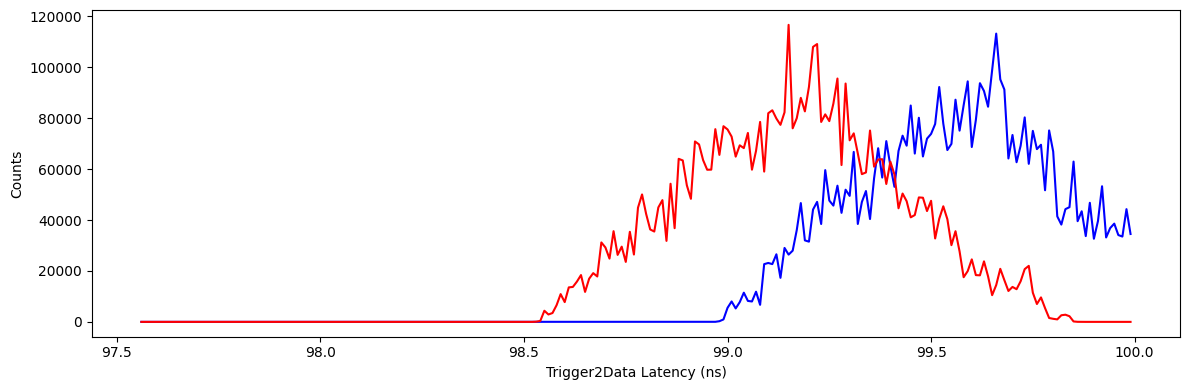

In [17]:
# Configure & run measurements
MEASUREMENT_TIME_HIST = 5e12
BINWIDTH = 10
N_BINS = 10e3
sync_meas = SynchronizedMeasurements(ttx)
sync_tagger = sync_meas.getTagger()
hist_1 = Histogram(sync_tagger, AUX_IN_CHANNEL_1, TRIGGER_CHANNEL, binwidth=BINWIDTH, n_bins=N_BINS)
hist_2 = Histogram(sync_tagger, AUX_IN_CHANNEL_2, TRIGGER_CHANNEL, binwidth=BINWIDTH, n_bins=N_BINS)
sync_meas.startFor(MEASUREMENT_TIME_HIST)
sync_meas.waitUntilFinished()
hist1_index = hist_1.getIndex() * 1e-3  # Convert to ns
hist1_data = hist_1.getData()
hist2_index = hist_2.getIndex() * 1e-3
hist2_data = hist_2.getData()

# Find mean and FWHM for both histograms
auxout1_latency, fwhm_1 = find_mean_fwhm(hist1_index, hist1_data)
auxout2_latency, fwhm_2 = find_mean_fwhm(hist2_index, hist2_data)

print("------------------------------")
print(f"Mean Aux Out 1 latency: {auxout1_latency:2.1f} +- {fwhm_1/np.sqrt(12):0.1f} ns")
print(f"Mean Aux Out 2 latency: {auxout2_latency:2.1f} +- {fwhm_2/np.sqrt(12):0.1f} ns")
print("------------------------------")

# Plot Trigger2Data histograms
fig = plt.figure(figsize=(12, 4))

zoom_range = 2  # ns
zoom_min = auxout1_latency - zoom_range
zoom_max = auxout1_latency + zoom_range
mask1 = (hist1_index >= zoom_min) & (hist1_index <= zoom_max)
mask2 = (hist2_index >= zoom_min) & (hist2_index <= zoom_max)
plt.plot(hist1_index[mask1], hist1_data[mask1], label='Trigger2Data AuxOut 1', color='b')
plt.plot(hist2_index[mask2], hist2_data[mask2], label='Trigger2Data AuxOut 2', color='r')
plt.xlabel("Trigger2Data Latency (ns)")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()


Remarks:
- the Trigger2Data latency here includes the cable delay between the Aux Out and Aux In channels.
- the jitter histogram is expected to show a uniform distribution of 670 ps FWHM ($670/\sqrt(12)=193$ ps RMS) which originates from the 1.5 Gbit/s data rate of the Aux Out driver. However, in this setup the Aux Out pulses are measured using the Aux In channels of the same device i.e. they are running both synchronous to the same FPGA clock.


## 4. Stop Fast-Feedback Module and Release Time Tagger

To stop the fast-feedback module sending output pulses, the `disableOutputs` method can be used, which overwrites the active channel and coincidence masks.

In [18]:
FFC.disableOutputs()

freeTimeTagger(ttx)